# Análise integrada — risco climático, produtividade prevista e viabilidade econômica

Este notebook integra os dois eixos do `09_analise_custo_modelos.ipynb` (risco climático via ISNA e
risco/viabilidade econômica via série SEAB/DERAL) com um **terceiro eixo independente: a
produtividade prevista pelo modelo `ExtraTrees.joblib`** — a mesma estimativa que já alimenta o
eixo econômico do `09`, mas aqui usada diretamente, sem passar pelo custo/preço.

Motivação: o ISNA (`ETR/ETc`) captura só o componente hídrico do balanço de água no solo. O
ExtraTrees usa ~65 features (temperatura, umidade relativa, radiação/ETo, timing de fases,
altitude, coordenadas etc.) além do próprio ISNA por fase — ou seja, a produtividade prevista
carrega informação agronômica que o ISNA sozinho não vê. A seção 2 mede a correlação entre os dois
pra deixar claro o quanto essa informação é (ou não) redundante antes de combiná-los.

Este notebook **não refaz a simulação climática nem a inferência** — reaproveita os CSVs já
exportados pelo `09_analise_custo_modelos.ipynb` (`previsoes_oeste_pr.csv`,
`risco_climatico_oeste_pr.csv`, `risco_economico_oeste_pr.csv`). Se o `09` for reexecutado com
dados novos, reexecute este notebook em seguida.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pd.set_option("display.width", 160)
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

previsoes = pd.read_csv("previsoes_oeste_pr.csv")
risco_climatico = pd.read_csv("risco_climatico_oeste_pr.csv")
risco_economico = pd.read_csv("risco_economico_oeste_pr.csv")
melhor_data_09 = pd.read_csv("melhor_data_semeadura_por_municipio.csv")

SEM = ["05/02/", "15/02/", "25/02/", "05/03/", "15/03/", "25/03/"]

print(previsoes.shape, risco_climatico.shape, risco_economico.shape)
previsoes.head(3)

(8100, 4) (300, 6) (300, 6)


,municipio,ano,data_semeadura,produtividade_prevista_kg_ha
0,Anahy,2019,05/02/,2940.726180
1,Anahy,2019,15/02/,3133.112355
2,Anahy,2019,25/02/,2875.978996


## 1. Novo eixo — produtividade prevista (ExtraTrees)

Para cada (município, data de semeadura), calculamos a média e o desvio-padrão da
`produtividade_prevista_kg_ha` nos 27 anos simulados (1999-2025, mesma base do eixo climático — não
os 26 anos do eixo econômico, já que aqui não depende da série DERAL). Classificamos em **tercis**
(mesmo método usado no eixo econômico do `09`), pra manter a mesma escala ordinal 0/1/2 nas três
dimensões.

In [2]:
produtividade_cidade_data = (
    previsoes.groupby(["municipio", "data_semeadura"])["produtividade_prevista_kg_ha"]
    .agg(produtividade_media_kg_ha="mean", produtividade_desvio_kg_ha="std", n_anos="count")
    .reset_index()
)

produtividade_cidade_data["classe_produtividade"] = pd.qcut(
    produtividade_cidade_data["produtividade_media_kg_ha"],
    q=3,
    labels=["Baixa produtividade prevista", "Produtividade prevista intermediária", "Alta produtividade prevista"],
).astype(str)

print(produtividade_cidade_data["classe_produtividade"].value_counts())
produtividade_cidade_data.sort_values("produtividade_media_kg_ha", ascending=False).head(15)

classe_produtividade
Alta produtividade prevista             100
Produtividade prevista intermediária    100
Baixa produtividade prevista            100
Name: count, dtype: int64


,municipio,data_semeadura,produtividade_media_kg_ha,produtividade_desvio_kg_ha,n_anos,classe_produtividade
74,Diamante do Sul,15/02/,3436.361728,327.450791,27,Alta produtividade prevista
50,Catanduvas,15/02/,3427.019118,377.482541,27,Alta produtividade prevista
98,Guaraniaçu,15/02/,3425.488127,379.607297,27,Alta produtividade prevista
52,Catanduvas,25/02/,3414.119400,369.493402,27,Alta produtividade prevista
110,Ibema,15/02/,3413.927184,387.865613,27,Alta produtividade prevista
112,Ibema,25/02/,3410.841034,377.328282,27,Alta produtividade prevista
46,Cascavel,25/02/,3405.620391,382.045053,27,Alta produtividade prevista
100,Guaraniaçu,25/02/,3404.090515,378.112842,27,Alta produtividade prevista
72,Diamante do Sul,05/02/,3402.397197,261.132343,27,Alta produtividade prevista
32,Campo Bonito,15/02/,3401.668453,381.093760,27,Alta produtividade prevista


## 2. ISNA × produtividade prevista — os dois eixos são redundantes?

Antes de combinar as três dimensões, vale medir o quanto o novo eixo é (ou não) apenas uma
repetição do ISNA — os dois deveriam variar juntos até certo ponto (água é o principal driver de
estresse no próprio modelo), mas se a correlação for muito alta o eixo novo agrega pouca informação
extra.

Pearson r = 0.849 (p=1.2e-84)
Spearman rho = 0.856 (p=1.9e-87)


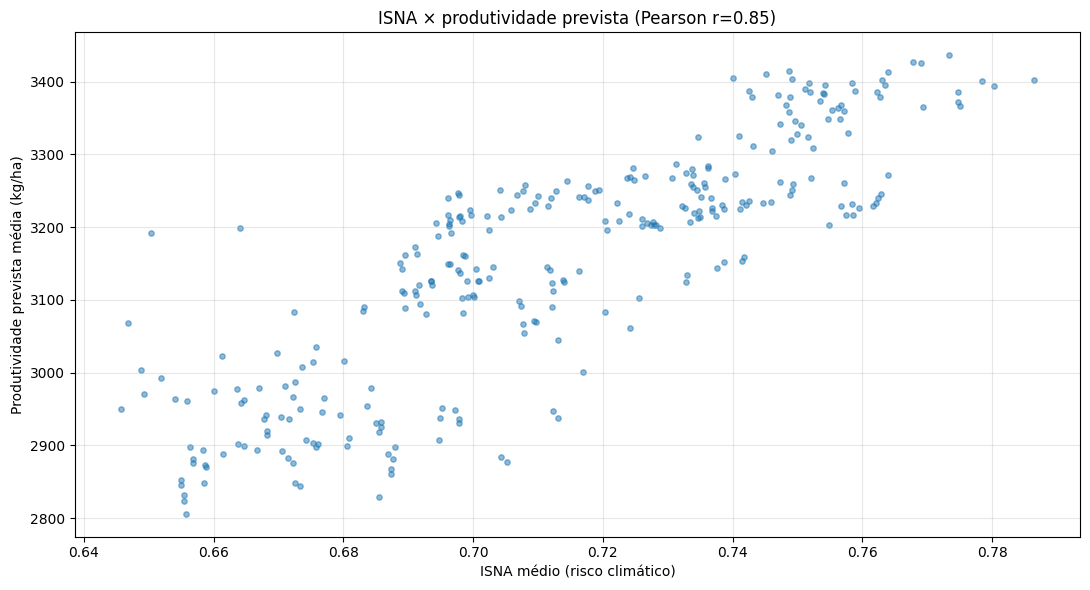

In [3]:
comparacao_isna_produtividade = risco_climatico[["municipio", "data_semeadura", "isna_medio"]].merge(
    produtividade_cidade_data[["municipio", "data_semeadura", "produtividade_media_kg_ha"]],
    on=["municipio", "data_semeadura"],
)

r_pearson, p_pearson = stats.pearsonr(
    comparacao_isna_produtividade["isna_medio"], comparacao_isna_produtividade["produtividade_media_kg_ha"]
)
r_spearman, p_spearman = stats.spearmanr(
    comparacao_isna_produtividade["isna_medio"], comparacao_isna_produtividade["produtividade_media_kg_ha"]
)
print(f"Pearson r = {r_pearson:.3f} (p={p_pearson:.1e})")
print(f"Spearman rho = {r_spearman:.3f} (p={p_spearman:.1e})")

fig, ax = plt.subplots()
ax.scatter(
    comparacao_isna_produtividade["isna_medio"],
    comparacao_isna_produtividade["produtividade_media_kg_ha"],
    alpha=0.5, s=15,
)
ax.set_xlabel("ISNA médio (risco climático)")
ax.set_ylabel("Produtividade prevista média (kg/ha)")
ax.set_title(f"ISNA × produtividade prevista (Pearson r={r_pearson:.2f})")
plt.tight_layout()
plt.show()

A correlação observada é **forte (Pearson r ≈ 0,85; Spearman ρ ≈ 0,86)** — nada surpreendente,
já que o déficit hídrico é o principal driver de perda de produtividade que o próprio modelo
aprendeu. Mas está longe de 1,0, o que indica que a produtividade prevista carrega sinal adicional
(temperatura, timing de fases, altitude) que o ISNA sozinho não captura. Vale ter em mente, porém,
que os dois eixos **não são independentes** — o `score_integrado` da seção 3 acaba ponderando o
componente hídrico duas vezes (ver seção 5, limitações).

## 3. Matriz integrada — três eixos combinados

Une os três eixos (clima, produtividade, econômico) por (município, data de semeadura) numa única
tabela, com a mesma lógica ordinal 0 (melhor) a 2 (pior) por eixo usada no `09`, agora somando os
três num `score_integrado` (0 = melhor nos três eixos, 6 = pior nos três).

In [4]:
matriz_integrada = (
    risco_climatico
    .merge(produtividade_cidade_data.drop(columns="n_anos"), on=["municipio", "data_semeadura"])
    .merge(
        risco_economico[["municipio", "data_semeadura", "pct_anos_cobre_custo", "margem_media_rs_ha", "risco_economico"]],
        on=["municipio", "data_semeadura"],
    )
)

ORDEM_CLIMA = {"Baixo risco climático": 0, "Médio risco climático": 1, "Alto risco climático": 2}
ORDEM_PRODUTIVIDADE = {
    "Alta produtividade prevista": 0,
    "Produtividade prevista intermediária": 1,
    "Baixa produtividade prevista": 2,
}
ORDEM_ECONOMICO = {"Mais viável": 0, "Viabilidade intermediária": 1, "Menos viável": 2}

matriz_integrada["score_clima"] = matriz_integrada["risco_climatico"].map(ORDEM_CLIMA).astype(int)
matriz_integrada["score_produtividade"] = matriz_integrada["classe_produtividade"].map(ORDEM_PRODUTIVIDADE).astype(int)
matriz_integrada["score_economico"] = matriz_integrada["risco_economico"].map(ORDEM_ECONOMICO).astype(int)
matriz_integrada["score_integrado"] = (
    matriz_integrada["score_clima"] + matriz_integrada["score_produtividade"] + matriz_integrada["score_economico"]
)

matriz_integrada.to_csv("matriz_integrada_oeste_pr.csv", index=False, encoding="utf-8-sig")

print("Distribuição do score integrado (0=melhor, 6=pior):")
print(matriz_integrada["score_integrado"].value_counts().sort_index())
matriz_integrada.sort_values("score_integrado").head(10)

Distribuição do score integrado (0=melhor, 6=pior):
score_integrado
0    90
1    20
2    81
3    17
4    89
5     3
Name: count, dtype: int64


,municipio,data_semeadura,isna_medio,isna_desvio,n_anos,risco_climatico,produtividade_media_kg_ha,produtividade_desvio_kg_ha,classe_produtividade,pct_anos_cobre_custo,margem_media_rs_ha,risco_economico,score_clima,score_produtividade,score_economico,score_integrado
28,Cafelândia,25/02/,0.697699,0.108422,27,Baixo risco climático,3247.271965,400.122685,Alta produtividade prevista,3.8,-873.365713,Mais viável,0,0,0,0
30,Campo Bonito,05/02/,0.774672,0.102205,27,Baixo risco climático,3372.283423,323.786237,Alta produtividade prevista,3.8,-848.414403,Mais viável,0,0,0,0
27,Cafelândia,15/03/,0.704115,0.108177,27,Baixo risco climático,3251.064162,408.184938,Alta produtividade prevista,7.7,-872.698256,Mais viável,0,0,0,0
31,Campo Bonito,05/03/,0.748261,0.098803,27,Baixo risco climático,3368.439251,389.122823,Alta produtividade prevista,3.8,-835.057953,Mais viável,0,0,0,0
298,Vera Cruz do Oeste,25/02/,0.719459,0.097998,27,Baixo risco climático,3250.570830,467.616900,Alta produtividade prevista,7.7,-861.987501,Mais viável,0,0,0,0
47,Cascavel,25/03/,0.748831,0.114202,27,Baixo risco climático,3378.327961,352.889745,Alta produtividade prevista,7.7,-836.504633,Mais viável,0,0,0,0
45,Cascavel,15/03/,0.753858,0.097990,27,Baixo risco climático,3384.819696,375.999286,Alta produtividade prevista,7.7,-834.361878,Mais viável,0,0,0,0
46,Cascavel,25/02/,0.740043,0.095847,27,Baixo risco climático,3405.620391,382.045053,Alta produtividade prevista,7.7,-825.539941,Mais viável,0,0,0,0
40,Capitão Leônidas Marques,25/02/,0.732853,0.092913,27,Baixo risco climático,3274.123133,495.596453,Alta produtividade prevista,7.7,-851.167821,Mais viável,0,0,0,0
42,Cascavel,05/02/,0.769379,0.101617,27,Baixo risco climático,3365.066757,355.504909,Alta produtividade prevista,3.8,-851.567845,Mais viável,0,0,0,0


## 4. Melhor data de semeadura por município — comparação com o eixo duplo (`09`)

Mesma lógica de seleção do `09` (menor `score`, com desempate pela métrica mais informativa
disponível — aqui, maior produtividade prevista), agora sobre os três eixos. Comparamos com o
resultado do `09` (dois eixos) pra ver o quanto a inclusão da produtividade prevista muda a
recomendação.

In [5]:
melhor_data_integrada = (
    matriz_integrada
    .sort_values(["municipio", "score_integrado", "produtividade_media_kg_ha"], ascending=[True, True, False])
    .groupby("municipio")
    .first()
    .reset_index()[[
        "municipio", "data_semeadura", "risco_climatico", "classe_produtividade", "risco_economico",
        "produtividade_media_kg_ha", "score_integrado",
    ]]
)
melhor_data_integrada.to_csv("melhor_data_semeadura_integrada.csv", index=False, encoding="utf-8-sig")

comparacao_09 = melhor_data_09[["municipio", "data_semeadura"]].merge(
    melhor_data_integrada[["municipio", "data_semeadura"]],
    on="municipio", suffixes=("_09_dois_eixos", "_integrado"),
)
mudou = comparacao_09["data_semeadura_09_dois_eixos"] != comparacao_09["data_semeadura_integrado"]
print(f"Municípios com data recomendada diferente: {mudou.sum()} / {len(comparacao_09)}")
comparacao_09[mudou]

Municípios com data recomendada diferente: 35 / 50


,municipio,data_semeadura_09_dois_eixos,data_semeadura_integrado
0,Anahy,05/03/,05/02/
1,Assis Chateaubriand,05/02/,25/03/
2,Boa Vista da Aparecida,05/02/,15/02/
3,Braganey,05/02/,15/02/
5,Campo Bonito,05/02/,15/02/
6,Capitão Leônidas Marques,25/03/,25/02/
7,Cascavel,05/02/,25/02/
8,Catanduvas,05/02/,15/02/
9,Corbélia,05/02/,15/03/
10,Céu Azul,15/03/,05/03/


### Mapa de calor — score integrado por município × data de semeadura

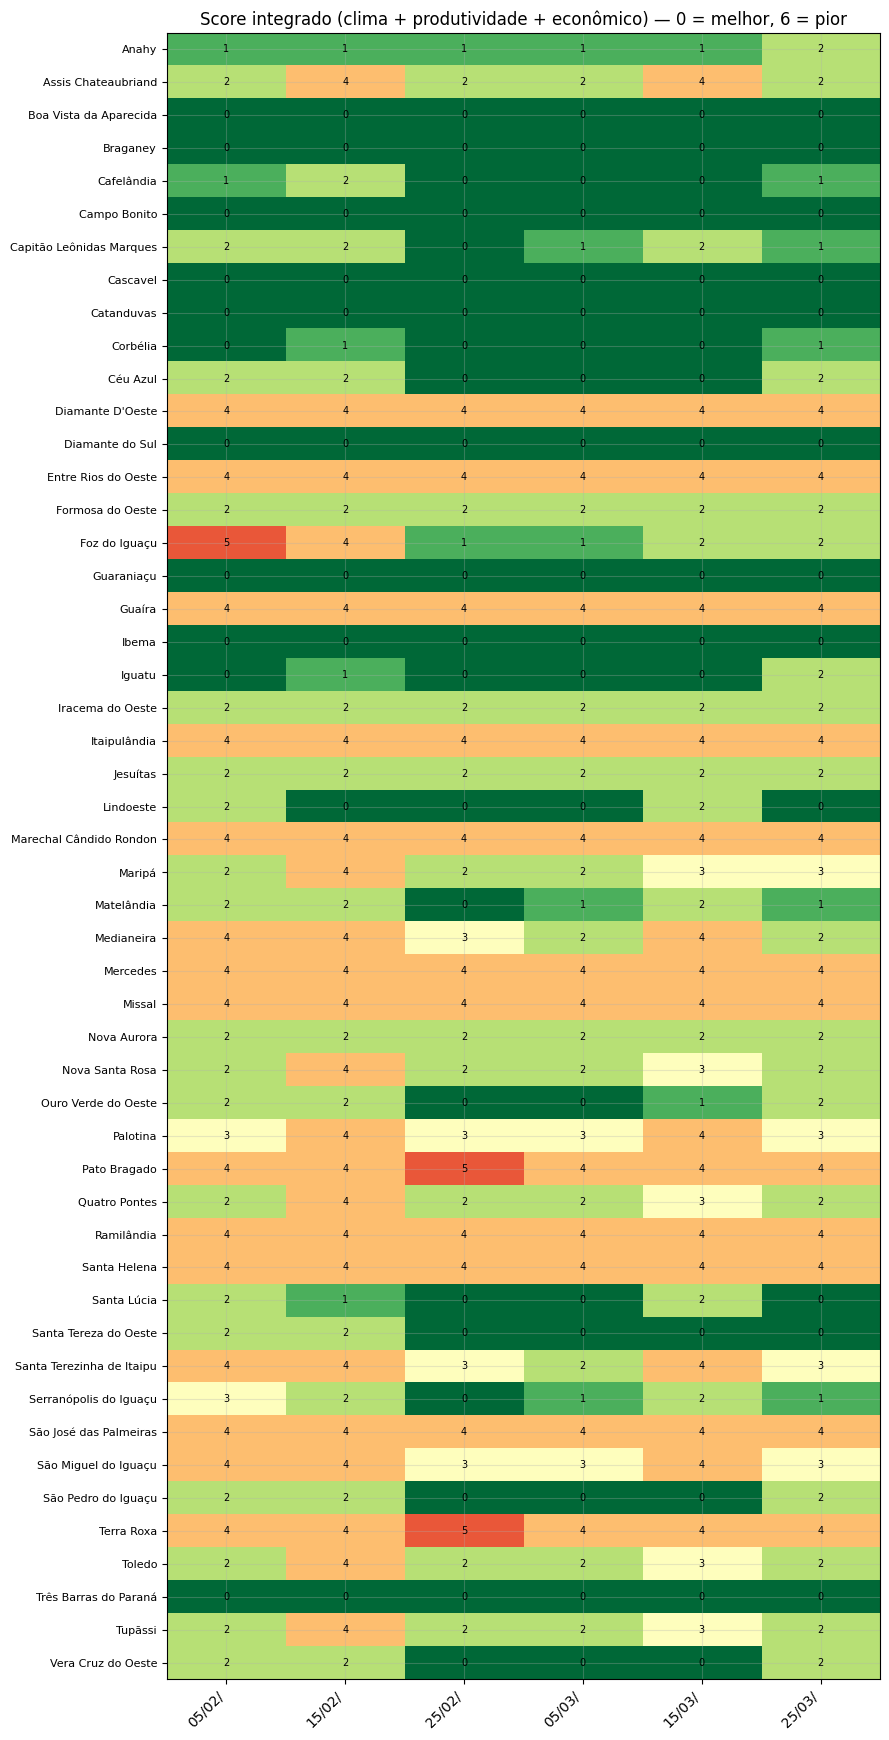

In [6]:
pivot_score_integrado = matriz_integrada.pivot(index="municipio", columns="data_semeadura", values="score_integrado")[SEM]

fig, ax = plt.subplots(figsize=(9, max(6, 0.35 * len(pivot_score_integrado))))
im = ax.imshow(pivot_score_integrado, cmap="RdYlGn_r", vmin=0, vmax=6, aspect="auto")
ax.set_xticks(range(len(SEM)))
ax.set_xticklabels(SEM, rotation=45, ha="right")
ax.set_yticks(range(len(pivot_score_integrado.index)))
ax.set_yticklabels(pivot_score_integrado.index, fontsize=8)
for i in range(pivot_score_integrado.shape[0]):
    for j in range(pivot_score_integrado.shape[1]):
        v = pivot_score_integrado.iloc[i, j]
        if pd.notna(v):
            ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=7)
ax.set_title("Score integrado (clima + produtividade + econômico) — 0 = melhor, 6 = pior")
plt.tight_layout()
plt.show()

## 5. PCA — componente agroclimático (clima + produtividade)

A soma ordinal por tercis da seção 3 pondera o componente hídrico duas vezes (a correlação de 0,85
entre ISNA e produtividade prevista, vista na seção 2, significa que os dois eixos carregam boa
parte da mesma informação). Para resolver isso de forma mais rigorosa, aplicamos **PCA** sobre as
duas variáveis padronizadas (`isna_medio`, `produtividade_media_kg_ha`) e extraímos o primeiro
componente principal como um **único eixo agroclimático**, sem redundância entre clima e
produtividade.

In [7]:
X_clima_produtividade = StandardScaler().fit_transform(
    matriz_integrada[["isna_medio", "produtividade_media_kg_ha"]].to_numpy()
)

pca = PCA(n_components=1)
componente_agroclimatico = pca.fit_transform(X_clima_produtividade).ravel()

# PCA não garante o sinal do componente — orienta pra que valores maiores = melhor (mais próximo de
# alta produtividade prevista / baixo risco climático)
if np.corrcoef(componente_agroclimatico, matriz_integrada["produtividade_media_kg_ha"])[0, 1] < 0:
    componente_agroclimatico = -componente_agroclimatico

matriz_integrada["componente_agroclimatico"] = componente_agroclimatico

print(f"Variância explicada pelo 1º componente: {pca.explained_variance_ratio_[0]:.1%}")
matriz_integrada[
    ["municipio", "data_semeadura", "isna_medio", "produtividade_media_kg_ha", "componente_agroclimatico"]
].sort_values("componente_agroclimatico", ascending=False).head(10)

Variância explicada pelo 1º componente: 92.5%


,municipio,data_semeadura,isna_medio,produtividade_media_kg_ha,componente_agroclimatico
72,Diamante do Sul,05/02/,0.786501,3402.397197,2.658725
74,Diamante do Sul,15/02/,0.773392,3436.361728,2.528973
96,Guaraniaçu,05/02/,0.780250,3394.477472,2.491726
48,Catanduvas,05/02/,0.778491,3400.938955,2.482621
98,Guaraniaçu,15/02/,0.769103,3425.488127,2.390674
50,Catanduvas,15/02/,0.767835,3427.019118,2.370485
108,Ibema,05/02/,0.774810,3386.472571,2.341539
30,Campo Bonito,05/02/,0.774672,3372.283423,2.276760
18,Braganey,05/02/,0.775017,3366.104875,2.257129
110,Ibema,15/02/,0.763993,3413.927184,2.231988


## 6. TOPSIS — ranking do risco integrado (agroclimático × econômico)

Com a redundância climática resolvida (um único `componente_agroclimatico`), aplicamos **TOPSIS**
(Technique for Order Preference by Similarity to Ideal Solution) sobre dois critérios — ambos "quanto
maior, melhor" (*benefício*):

1. `componente_agroclimatico` (clima + produtividade, via PCA)
2. `margem_media_rs_ha` (viabilidade econômica, contínua — não os tercis de `risco_economico`)

Passos do método: normalização vetorial de cada critério, aplicação de pesos (aqui, **50/50** entre
os dois critérios — mesma lógica de peso igual já usada no `score_integrado`, mas agora sem contar a
água duas vezes), cálculo da distância euclidiana à solução ideal (melhor valor de cada critério) e
à solução anti-ideal (pior valor), e o **coeficiente de proximidade** `C = distância_anti-ideal /
(distância_ideal + distância_anti-ideal)` — varia de 0 (pior) a 1 (melhor) e resume os dois
critérios preservando a magnitude real das diferenças (diferente da soma ordinal de tercis).

In [8]:
criterios = matriz_integrada[["componente_agroclimatico", "margem_media_rs_ha"]].to_numpy()
pesos = np.array([0.5, 0.5])  # ajuste aqui se algum critério for considerado mais importante

norm = criterios / np.sqrt((criterios ** 2).sum(axis=0))
matriz_pesada = norm * pesos

solucao_ideal = matriz_pesada.max(axis=0)       # melhor valor de cada critério (ambos "quanto maior, melhor")
solucao_anti_ideal = matriz_pesada.min(axis=0)

dist_ideal = np.sqrt(((matriz_pesada - solucao_ideal) ** 2).sum(axis=1))
dist_anti_ideal = np.sqrt(((matriz_pesada - solucao_anti_ideal) ** 2).sum(axis=1))

matriz_integrada["topsis_score"] = dist_anti_ideal / (dist_ideal + dist_anti_ideal)
matriz_integrada["classe_risco_topsis"] = pd.qcut(
    matriz_integrada["topsis_score"], q=3,
    labels=["Alto risco integrado", "Risco integrado intermediário", "Baixo risco integrado"],
).astype(str)

matriz_integrada.to_csv("matriz_topsis_oeste_pr.csv", index=False, encoding="utf-8-sig")

print(matriz_integrada["classe_risco_topsis"].value_counts())
matriz_integrada.sort_values("topsis_score", ascending=False)[
    ["municipio", "data_semeadura", "componente_agroclimatico", "margem_media_rs_ha", "topsis_score", "classe_risco_topsis"]
].head(10)

classe_risco_topsis
Baixo risco integrado            100
Risco integrado intermediário    100
Alto risco integrado             100
Name: count, dtype: int64


,municipio,data_semeadura,componente_agroclimatico,margem_media_rs_ha,topsis_score,classe_risco_topsis
72,Diamante do Sul,05/02/,2.658725,-835.813445,0.996303,Baixo risco integrado
74,Diamante do Sul,15/02/,2.528973,-825.252747,0.975866,Baixo risco integrado
96,Guaraniaçu,05/02/,2.491726,-840.835385,0.968539,Baixo risco integrado
48,Catanduvas,05/02/,2.482621,-838.649946,0.966955,Baixo risco integrado
98,Guaraniaçu,15/02/,2.390674,-830.536766,0.950115,Baixo risco integrado
50,Catanduvas,15/02/,2.370485,-830.073739,0.946371,Baixo risco integrado
108,Ibema,05/02/,2.341539,-843.805494,0.940735,Baixo risco integrado
30,Campo Bonito,05/02/,2.276760,-848.414403,0.928625,Baixo risco integrado
18,Braganey,05/02/,2.257129,-849.800749,0.924955,Baixo risco integrado
110,Ibema,15/02/,2.231988,-833.608041,0.920603,Baixo risco integrado


### Melhor data de semeadura por município — via TOPSIS

Maior `topsis_score` por município (sem necessidade de desempate — o score é contínuo). Comparamos
com as duas versões anteriores: o resultado de dois eixos do `09` e a soma ordinal de tercis (seção
4 deste notebook).

In [9]:
melhor_data_topsis = (
    matriz_integrada.sort_values(["municipio", "topsis_score"], ascending=[True, False])
    .groupby("municipio")
    .first()
    .reset_index()[[
        "municipio", "data_semeadura", "componente_agroclimatico", "margem_media_rs_ha",
        "topsis_score", "classe_risco_topsis",
    ]]
)
melhor_data_topsis.to_csv("melhor_data_semeadura_topsis.csv", index=False, encoding="utf-8-sig")

comparacao_topsis_09 = melhor_data_09[["municipio", "data_semeadura"]].merge(
    melhor_data_topsis[["municipio", "data_semeadura"]], on="municipio", suffixes=("_09_dois_eixos", "_topsis")
)
comparacao_topsis_ordinal = melhor_data_integrada[["municipio", "data_semeadura"]].merge(
    melhor_data_topsis[["municipio", "data_semeadura"]], on="municipio", suffixes=("_ordinal_tercis", "_topsis")
)

mudou_09 = (comparacao_topsis_09["data_semeadura_09_dois_eixos"] != comparacao_topsis_09["data_semeadura_topsis"]).sum()
mudou_ordinal = (comparacao_topsis_ordinal["data_semeadura_ordinal_tercis"] != comparacao_topsis_ordinal["data_semeadura_topsis"]).sum()

print(f"TOPSIS vs 09 (dois eixos): {mudou_09} / 50 municípios com data diferente")
print(f"TOPSIS vs soma ordinal de tercis (seção 4): {mudou_ordinal} / 50 municípios com data diferente")
melhor_data_topsis.sort_values("topsis_score", ascending=False).head(10)

TOPSIS vs 09 (dois eixos): 8 / 50 municípios com data diferente
TOPSIS vs soma ordinal de tercis (seção 4): 35 / 50 municípios com data diferente


,municipio,data_semeadura,componente_agroclimatico,margem_media_rs_ha,topsis_score,classe_risco_topsis
12,Diamante do Sul,05/02/,2.658725,-835.813445,0.996303,Baixo risco integrado
16,Guaraniaçu,05/02/,2.491726,-840.835385,0.968539,Baixo risco integrado
8,Catanduvas,05/02/,2.482621,-838.649946,0.966955,Baixo risco integrado
18,Ibema,05/02/,2.341539,-843.805494,0.940735,Baixo risco integrado
5,Campo Bonito,05/02/,2.276760,-848.414403,0.928625,Baixo risco integrado
3,Braganey,05/02/,2.257129,-849.800749,0.924955,Baixo risco integrado
7,Cascavel,05/02/,2.133108,-851.567845,0.901947,Baixo risco integrado
47,Três Barras do Paraná,15/02/,1.751950,-837.608228,0.831374,Baixo risco integrado
2,Boa Vista da Aparecida,15/03/,1.576974,-846.145055,0.798784,Baixo risco integrado
23,Lindoeste,25/03/,1.473332,-862.716749,0.779329,Baixo risco integrado


### Mapa de calor — score TOPSIS por município × data de semeadura

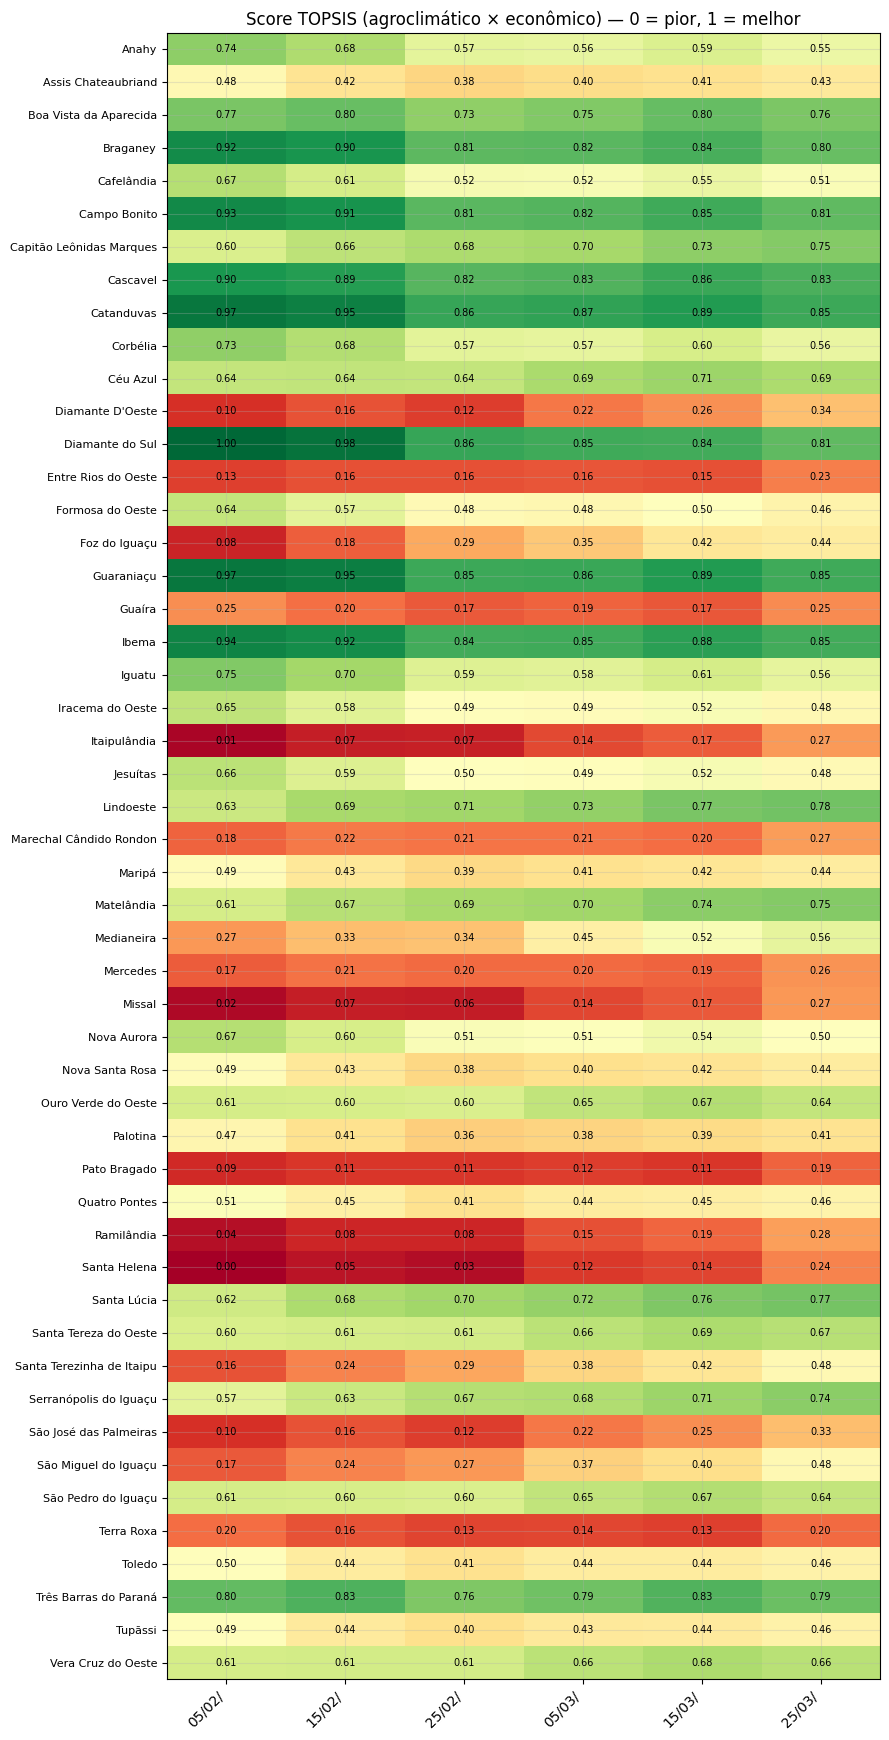

In [10]:
pivot_topsis = matriz_integrada.pivot(index="municipio", columns="data_semeadura", values="topsis_score")[SEM]

fig, ax = plt.subplots(figsize=(9, max(6, 0.35 * len(pivot_topsis))))
im = ax.imshow(pivot_topsis, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(SEM)))
ax.set_xticklabels(SEM, rotation=45, ha="right")
ax.set_yticks(range(len(pivot_topsis.index)))
ax.set_yticklabels(pivot_topsis.index, fontsize=8)
for i in range(pivot_topsis.shape[0]):
    for j in range(pivot_topsis.shape[1]):
        v = pivot_topsis.iloc[i, j]
        if pd.notna(v):
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7)
ax.set_title("Score TOPSIS (agroclimático × econômico) — 0 = pior, 1 = melhor")
plt.tight_layout()
plt.show()

## 7. Limitações a considerar

**Sobre a soma ordinal de tercis (seção 3):**
- Pondera o componente hídrico duas vezes (ISNA e produtividade prevista têm correlação de 0,85) —
  é o problema que a PCA da seção 5 resolve.
- Tercis por eixo perdem magnitude (duas datas com ISNA de 0,70 e 0,64 podem cair no mesmo tercil,
  enquanto 0,64 e 0,63 caem em tercis diferentes) e geram empates frequentes de `score_integrado`
  (ver distribuição na seção 3).

**Sobre PCA + TOPSIS (seções 5-6):**
- **Pesos 50/50 entre componente agroclimático e margem econômica são uma escolha arbitrária**,
  mesma lógica de peso igual usada no score ordinal — ajustáveis diretamente no vetor `pesos`, se
  algum critério for considerado mais relevante.
- **PCA assume relação linear** entre ISNA e produtividade prevista; a correlação de Pearson (0,85)
  sustenta essa suposição aqui, mas não é validada formalmente (ex.: teste de linearidade).
- O `componente_agroclimatico` é específico deste conjunto de 300 combinações — recalculá-lo com um
  conjunto de municípios/anos diferente muda a escala (mas não deveria mudar o ranking relativo de
  forma substancial, já que a correlação subjacente tende a ser estável).
- Produtividade prevista ainda usa 27 anos (1999-2025) e margem econômica usa 26 anos (1999-2024,
  limitado pela série DERAL) — os dois critérios do TOPSIS não compartilham exatamente a mesma
  janela temporal.
- **Tercis de `classe_risco_topsis` são relativos ao próprio cenário simulado** (300 combinações),
  igual aos demais eixos — não é um corte agronômico ou econômico absoluto.
- Depende dos CSVs exportados pelo `09_analise_custo_modelos.ipynb` — se esse notebook for
  reexecutado com dados/parâmetros novos, reexecute este notebook em seguida.